# Overview

The purpose of this notebook is to determine the boundaries of trigger activity search windows types: reject, inspect, accept.
The boundaries, in sum adc ranges terms, are determined from monte carlo dataset properties.
- **inspect/accept threshold**: 
  - Defined as the total window charge value at which the radiological windows accept rate is zero.
  - In practice, this is set at the upper endpoint of the total window charge (sum-adc) distrubution for radiologicals
  - In practice, the endpoint of the window sum adc distribution
- **reject/inspect threshold**: 
  - Defined as the total window charge corresponding to the cluster accept threshold in inspect widows.
    - TPs in inspect windows are clustered. If there is at least one cluster above (cluster) sum-adc threshold the window is accepted
    - Therefore, there is no point in inspecting windows below the cluster sum-adc threshold.
  - The actual value of the theshold is determined by establishing the acceptable trigger rate for the system, which is beyond the scope of this notebook
  - An initial (lower bound) value can be determined based on the cluster size distribution of the radiological background sample. The distribution presents a sharp falling edge. The base of the edge server is taken as reject/inspect threshold: the region below the edge is background dominated.


# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
from rich import print
import pandas as pd
import matplotlib.pyplot as plt

import hist
import mplhep as hep
import pandas as pd


# Data

Two samples: single electrons (1-100 MeV) and radiological

In [3]:
import dunetrg.data.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
# datasets = dctl.load('vd/1x8x14/3sig', load_rawadc=False, selection=dataset_names)
# datasets = dctl.load('vd/1x8x14/preprod', load_rawadc=False, selection=dataset_names)
datasets = dctl.load('vd/1x8x14/tp_filtered', load_rawadc=False, selection=dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Loading eminus

Key 'mcneutrinos' not found in file.
Key 'mcparticles' not found in file.
Key 'simides' not found in file.


Dataset 'eminus': 10000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    },
    'detector_properties': {'readout_window': 8500}
}

Loading radbkg

Dataset 'radbkg': 49785 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    },
    'detector_properties': {'readout_window': 8500}
}

In [4]:
rad_ws.info['mctruth_blockid_map']

[[28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
 [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
 [26, 'Kr85GenInLAr'],
 [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
 [24, 'U238ChainGenInAnode'],
 [23, 'K40GenInCathode'],
 [22, 'K42From42ArGenInUpperMesh1x8x14'],
 [21, 'Th232ChainGenInCathode'],
 [20, 'CavernNGammasAtLAr1x8x14'],
 [19, 'Rn222ChainRn222GenInLAr'],
 [18, 'U238ChainGenInCathode'],
 [17, 'K40GenInAnode'],
 [16, 'Rn220ChainPb212GenInLAr'],
 [15, 'foamGammasAtLAr1x8x14'],
 [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
 [13, 'K42From42ArGenInLAr'],
 [12, 'Rn222ChainGenInPDS'],
 [11, 'Ar42GenInLAr'],
 [10, 'CavernwallGammasAtLAr1x8x14'],
 [9, 'Rn222ChainPb210GenInLAr'],
 [8, 'Ar39GenInLAr'],
 [7, 'Rn222ChainPb214GenInLAr'],
 [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
 [5, 'Rn222ChainPo218GenInLAr'],
 [4, 'CavernwallNeutronsAtLAr1x8x14'],
 [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
 [2, 'CryostatNGammasAtLAr1x8x14'],
 [1, 'Th232ChainGenInAnode'],
 [0, 'Rn222

# Pre-Run Checks

## Background and Signal TPs properties
A routine check to confirm the absense of macroscopic features in the input datasets, and that the samples were properly filtered.

In [5]:
%%script false --no-raise-error


query=None
norm='rate'
geo_norm='crp'
n_top=10
rop=2


bkg_tpp = TrgPrimitivesPlotter(rad_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")



In [6]:
%%script false --no-raise-error


sig_tpp = TrgPrimitivesPlotter(em_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")

---

# Analyzer

In [7]:
from dunetrg.analysis.tawindows import Calibrator, TAWindowAnalyzer

# Analysis

Create window analyzers

In [8]:
rad_twa = TAWindowAnalyzer(rad_ws, 1000)
em_twa = TAWindowAnalyzer(em_ws, 1000)

### Electron calibration in cathode proximity
Create a calibrator object for later use and perform a quick self-consistency check

Use close-to-cathode values (calculated in the TPCalibration nb)

In [9]:
elec_calibrator = Calibrator(
    m = 2903.2,
    b = -5400
)

# Check the calibrator consistency
print(f"8000 sadcs -> {elec_calibrator.sadc_to_mev(8000):.2f} MeV")
print(f"5 MeV -> {elec_calibrator.mev_to_sadc(5):.2f} sadc")
print(f"sadc -> mev -> sadc : 8000 -> {elec_calibrator.mev_to_sadc(elec_calibrator.sadc_to_mev(8000))}")

8000 sadcs -> 4.62 MeV

5 MeV -> 9116.00 sadc

sadc -> mev -> sadc : 8000 -> 8000.000000000002

In [10]:
rad_twa.ta_wins.query('readout_plane_id == 2')

,event_uid,TPCSetID,readout_plane_id,tawin_id,n_tps,sadc
9,99010000001,62,2,8,1,795
10,99010000001,62,2,1,4,7024
11,99010000001,62,2,2,7,12769
12,99010000001,62,2,6,1,2467
13,99010000001,62,2,0,4,9650
...,...,...,...,...,...,...
24254058,99010462910,43,2,6,4,11092
24254059,99010462910,43,2,4,1,2273
24254060,99010462910,43,2,0,8,10003
24254061,99010462910,43,2,2,1,1772


## Check windows uniformity 
### 1. Across the simulated readout window (radbkg dataset)

The window distribution per plane is expected to be uniform in window id
Note: window is counted only if it contains at least a TP

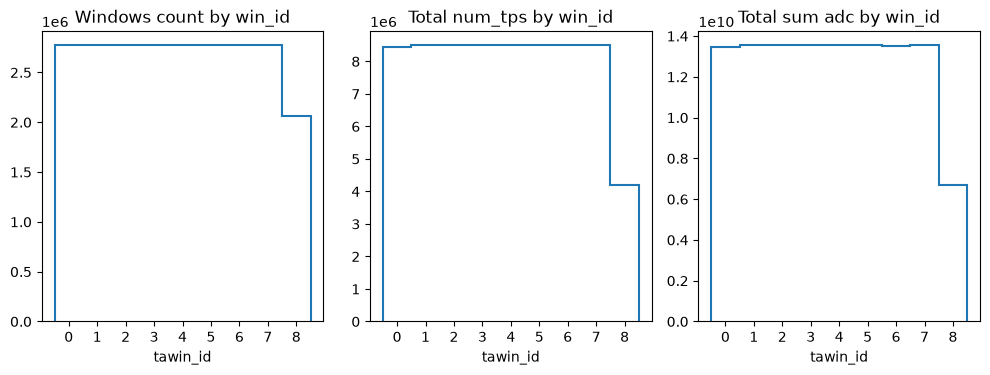

In [11]:
tawin_ax = hist.axis.Integer(0, rad_twa.ta_wins.tawin_id.max()+1, name='tawin_id')

h_tawin = hist.Hist(tawin_ax)
h_tawin.fill(tawin_id=rad_twa.ta_wins.tawin_id.values)

h_tawin_ntps = hist.Hist(tawin_ax)
h_tawin_ntps.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.n_tps)


h_tawin_sadc = hist.Hist(tawin_ax)
h_tawin_sadc.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.sadc)

fig, axes = plt.subplots(1,3, figsize=(10,4))
ax = axes[0]
hep.histplot(h_tawin, ax=ax)
ax.set_title("Windows count by win_id")

ax = axes[1]

hep.histplot(h_tawin_ntps, ax=ax)
ax.set_title("Total num_tps by win_id")

ax = axes[2]
hep.histplot(h_tawin_sadc, ax=ax)
ax.set_title("Total sum adc by win_id")


fig.tight_layout()


### 2. Across readout planes (radbkg dataset)

Since only windows with $n_{TPs} > 0$ are counted, the collection plane is expected to be the most populated

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x4fd099400>, cbar=<matplotlib.colorbar.Colorbar object at 0x4fec986e0>, text=[])

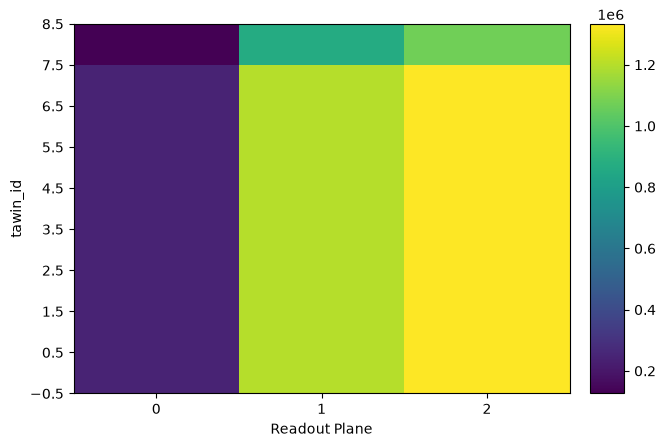

In [12]:
h = rad_twa.make_tawin_hist({'name':'tawin_id', 'bin_size': 1, 'type': 'int'})
hep.hist2dplot(h)

# Inspect/Accept Threshold
## Window SumADC and Num TPs for backgrounds and $e^-$

[(3.4431077984280276, 2.0066870198580005)]

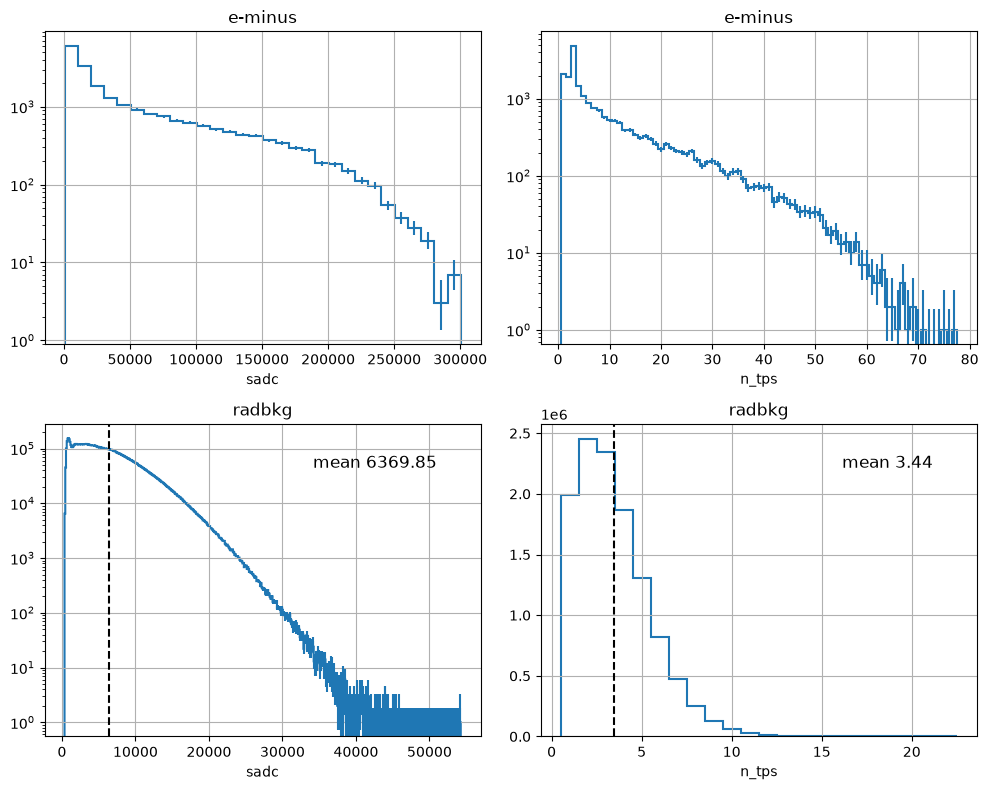

In [13]:
from dunetrg.analysis.histograms import hist_stats


rop=2j

fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
h = em_twa.make_tawin_hist({'name':'sadc', 'bin_size': 10000})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()


ax=axes[0][1]
h = em_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()

ax=axes[1][0]
h = rad_twa.make_tawin_hist({'name':'sadc', 'bin_size': 100})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('radbkg')
mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()


ax=axes[1][1]
h = rad_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
print(hist_stats(h[rop,:]))
ax.set_title('radbkg')

mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()

fig.tight_layout()

## Window 2D distributions

In [14]:
h_em = em_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])
h_rad = rad_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])

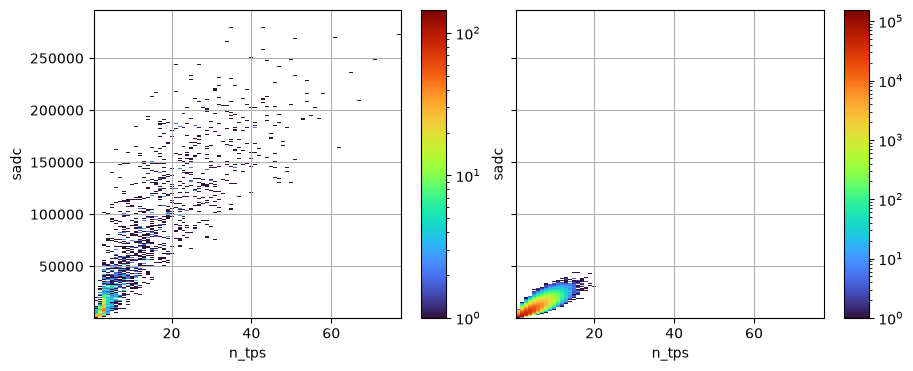

In [15]:
from matplotlib.colors import LogNorm


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
hep.hist2dplot(h_rad[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[1])
hep.hist2dplot(h_em[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[0])
axes[1].grid()
axes[0].grid()


## $e^{-}$ max(sum adc) / event vs radbkg sum adc comparison

How much does the e- window with the highest activity in the event compares to radiological windows?

In [16]:
em_sadc_max = (em_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)


rad_sadc_max = (rad_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)

Text(0.5, 1.0, 'radbkg - win sadc')

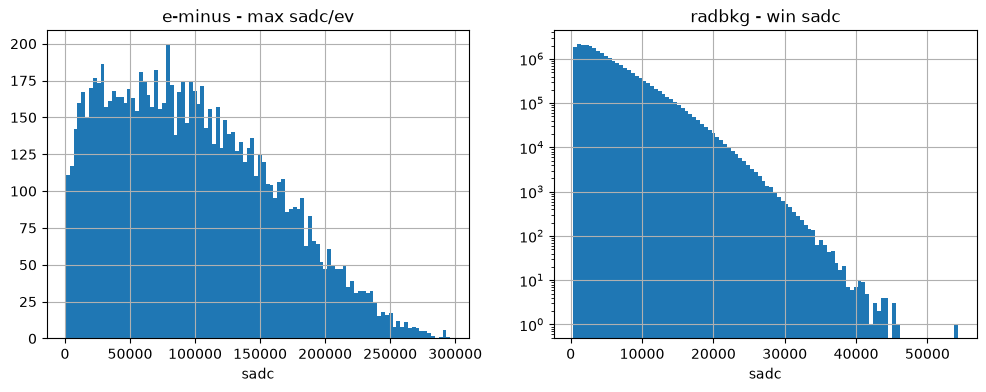

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

ax=axes[0]
em_sadc_max.sadc_max.hist(bins=100, ax=ax)

ax.set_title('e-minus - max sadc/ev')
ax.set_xlabel('sadc')


ax=axes[1]
rad_twa.ta_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('radbkg - win sadc')

### Observations
- Radiological window have a max sadc value of ~55k in the radiological dataset used
- 55k is likely to be an underestimate due to the dataset statistics
- The e- signal max-sadc-in-event (1-100 MeV) is well above the radiological endpoint
---

# Reject/Inspect Threshold

### Cluster making

### Define inspect windows and estimate inspect rate

- Select windows with charge above the radbkg average and below the bkg endpoint.
- Check TP multiplicity in inspect windows

                        Detector parameters                         
┌───────────────────────────────────────────────────┬──────────────┐
│ Window length                                     │ 1000 samples │
│ Window length                                     │ 0.0005 s     │
│ Num CRP                                           │ 28.0         │
│ Simulated readout time                            │ 2.1e+02s     │
│ Number of window expected per TPC                 │ 423172.5     │
│ Number of window expected (total)                 │ 47395320.0   │
│ Total number of windows (all planes)              │ 24254063     │
│ Total number of collection windows in the dataset │ 11734429     │
│ Number of windows per CRP                         │ 866216.54    │
│ Windows rate per CRP                              │ 4093.92 Hz   │
│ Selected inspect windows                          │ 4065392      │
│ Selected inspect windows ratio                    │ 0.17         │
│ Inspect rate per CRP                              │ 686.21 Hz    │
└───────────────────────────────────────────────────┴──────────────┘

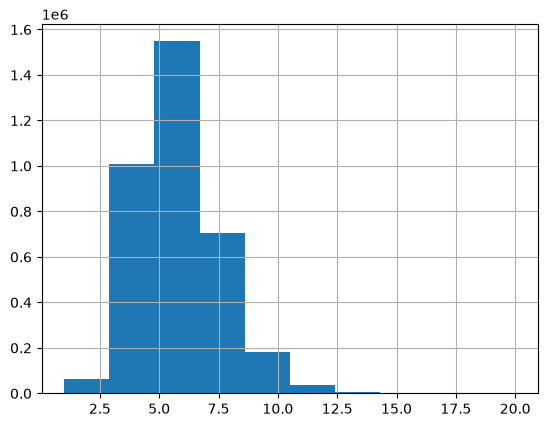

In [18]:
rop =2 
min_sadc = 8000
max_sadc = 50000
rad_insp_win = rad_twa.ta_wins.query(f'sadc > {min_sadc} & sadc < {max_sadc}')

rad_insp_win.query(f'readout_plane_id == {rop}').n_tps.hist()

rows = [
    ("Window length", f"{rad_twa.win_len} samples"),
    ("Window length", f"{rad_twa.win_len*0.5e-6} s"),
    ("Num CRP", f"{rad_twa.geo.num_crps}"),
    ("Simulated readout time", f"{rad_twa.simulated_readout_time():.2}s"),
    ("Number of window expected per TPC", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6):.1f}"),
    ("Number of window expected (total)", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6)*rad_twa.geo.num_tpcs:.1f}"),
    ("Total number of windows (all planes)", f"{len(rad_twa.ta_wins)}"),
    ("Total number of collection windows in the dataset", f"{len(rad_twa.ta_wins.query('readout_plane_id == 2'))}"),
    ("Number of windows per CRP", f"{len(rad_twa.ta_wins)/rad_twa.geo.num_crps:.2f}"),
    ("Windows rate per CRP", f"{len(rad_twa.ta_wins)/(rad_twa.geo.num_crps*rad_twa.simulated_readout_time()):.2f} Hz"),


    ("Selected inspect windows",f"{len(rad_insp_win)}"),
    ("Selected inspect windows ratio",f"{len(rad_insp_win)/len(rad_twa.ta_wins):.2f}"),
    ("Inspect rate per CRP", f"{len(rad_insp_win)/(rad_twa.simulated_readout_time()*rad_twa.geo.num_crps):.2f} Hz"),
    # All wins {len(rad_twa.ta_wins)} -> inspect {len(rad_insp_win)} ({len(rad_insp_win)/len(rad_twa.ta_wins):.3})
]

from rich.table import Table
t = Table(show_header=False)
t.title = 'Detector parameters'

for r in rows:

    t.add_row(r[0], f'[bold]{r[1]}[/bold]')


print(t)

In [19]:
from dunetrg.analysis.notebook import stop
stop("Skipping TA generation and analysis for now, as it takes a long time to run")


StopExecution: Skipping TA generation and analysis for now, as it takes a long time to run

## Collect TPs in the inspect windows and run the clustering algorithm

In [ ]:
keys = ['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id']
rad_insp_tps = rad_twa.tps_in_win.join(rad_insp_win.assign(_keep=True).set_index(keys), on=keys)

rad_insp_tps

mask  TPCSetID  adc_integral  adc_peak   bt_edep  \
entry subentry                                                     
0     0            0        62           765       122  0.830786   
      1            0        62          3247       581  2.353353   
      2            0        62           565        68  0.284733   
      3            0        62          1676       237  1.036893   
      4            0        62           446        64  0.366180   
...              ...       ...           ...       ...       ...   
12647 5711         0        43          6268       736  2.004376   
      5712         0        43          2891       507  0.983502   
      5713         0        43          2791       469  1.047014   
      5714         0        43          2759       446  0.840575   
      5715         0        43           939       147  0.377913   

                          bt_generator_name  bt_numelectrons  \
entry subentry                                                 
0     0                     K40GenInCathode     15291.539062   
      1         CavernwallGammasAtLAr1x8x14     67526.000000   
      2         CavernwallGammasAtLAr1x8x14      5350.000000   
      3         CavernwallGammasAtLAr1x8x14     28729.000000   
      4                        Ar39GenInLAr      8518.613281   
...                                     ...              ...   
12647 5711      CavernwallGammasAtLAr1x8x14     57420.000000   
      5712      CavernwallGammasAtLAr1x8x14     26908.000000   
      5713      CavernwallGammasAtLAr1x8x14     25183.000000   
      5714      CavernwallGammasAtLAr1x8x14     24889.000000   
      5715                     Ar39GenInLAr      8533.256836   

                bt_primary_track_energy_frac  bt_primary_track_id  \
entry subentry                                                      
0     0                                  1.0               127281   
      1                                  1.0                98815   
      2                                  1.0               110405   
      3                                  1.0                94019   
      4                                  1.0                 7408   
...                                      ...                  ...   
12647 5711                               1.0               101381   
      5712                               1.0                96259   
      5713                               1.0               113243   
      5714                               1.0               113243   
      5715                               1.0                 4052   

                bt_primary_track_numelectron_frac  ...  subrun    event_uid  \
entry subentry                                     ...                        
0     0                                       1.0  ...       0  99010000001   
      1                                       1.0  ...       0  99010000001   
      2                                       1.0  ...       0  99010000001   
      3                                       1.0  ...       0  99010000001   
      4                                       1.0  ...       0  99010000001   
...                                           ...  ...     ...          ...   
12647 5711                                    1.0  ...    4629  99010462910   
      5712                                    1.0  ...    4629  99010462910   
      5713                                    1.0  ...    4629  99010462910   
      5714                                    1.0  ...    4629  99010462910   
      5715                                    1.0  ...    4629  99010462910   

                time_peak  sample_start  sample_peak  bt_is_signal  tawin_id  \
entry subentry                                                                 
0     0            185088          5779         5784             1         5   
      1            159456          4977         4983             1         4   
      2            129568          4048         4049

In [ ]:
rad_insp_tps = rad_insp_tps[rad_insp_tps["_keep"] == True]
print(f'tps count = {len(rad_twa.tps_in_win)}, rad_insp_tps tps count {len(rad_insp_tps)}, ({len(rad_insp_tps)/len(rad_twa.tps_in_win):.3})')

KeyboardInterrupt: 

In [ ]:
from dunetrg.emu.tafinder.dbscan_numba import apply_dbscan
from tqdm import tqdm
tqdm.pandas(desc="numba tafinder!")

### Create radiological windows and calculate entries and sum adc for each

rad_insp_custers = (
    rad_insp_tps
    .groupby(['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id'], sort=False)
    .progress_apply(apply_dbscan, include_groups = False)
    .reset_index()
)

numba tafinder!: 100%|██████████| 4065392/4065392 [19:08<00:00, 3540.01it/s] 


In [ ]:
rad_insp_tps.loc[rad_insp_custers['tp_index'].iloc[5]]


# print(rad_insp_custers.n_clusters)
rad_insp_custers['dbscan_label']

rad_insp_custers.apply(
    lambda row: [(*pair, val) for pair, val in zip(row["tp_index"], row["dbscan_label"]) if val != -1],
    axis=1
)

0                                   [(0, 48, 0), (0, 49, 0)]
1                                                         []
2                                                         []
3                                   [(0, 69, 0), (0, 70, 0)]
4          [(0, 102, 0), (0, 103, 0), (0, 108, 1), (0, 10...
                                 ...                        
4065387                 [(12647, 5636, 0), (12647, 5637, 0)]
4065388                 [(12647, 5640, 0), (12647, 5641, 0)]
4065389                                                   []
4065390                 [(12647, 5713, 0), (12647, 5714, 0)]
4065391                                                   []
Length: 4065392, dtype: object

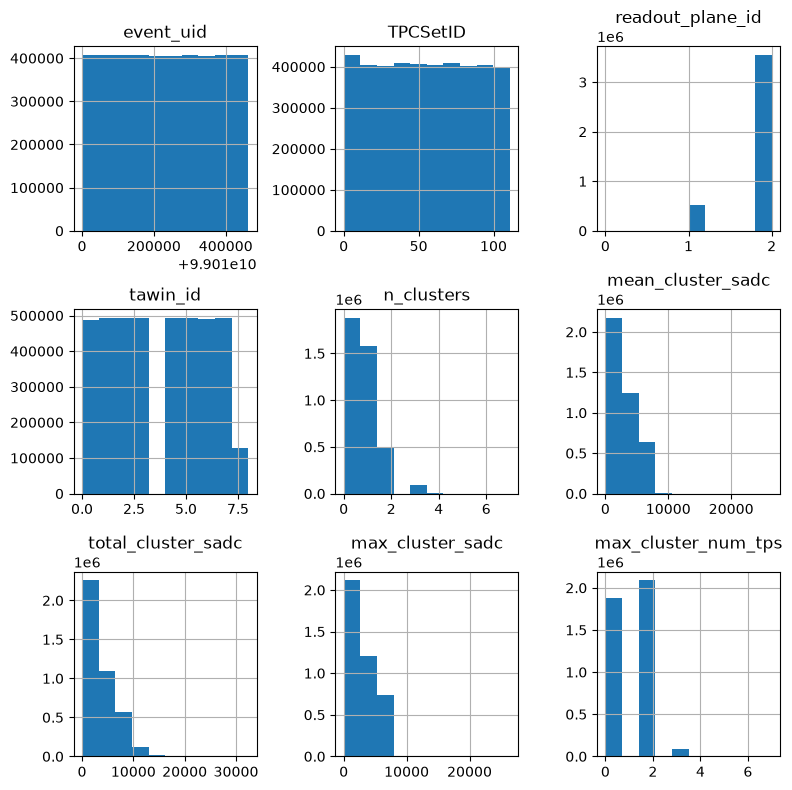

In [ ]:
rad_insp_custers.hist(figsize=(8,8))
plt.tight_layout()


4.615596583080739

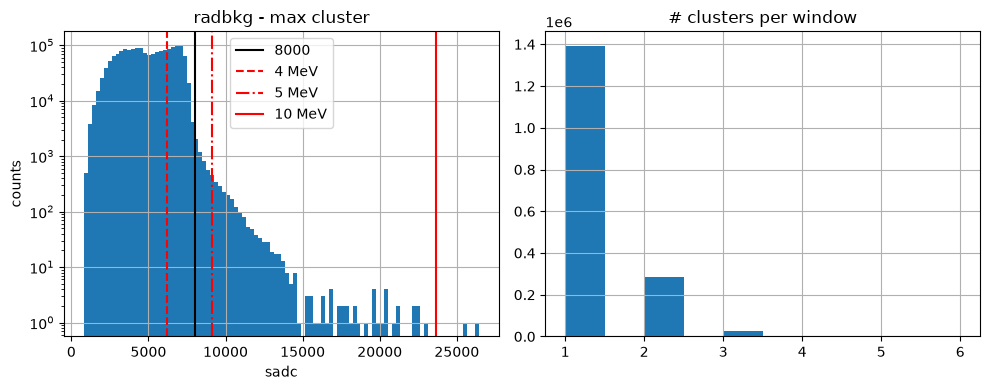

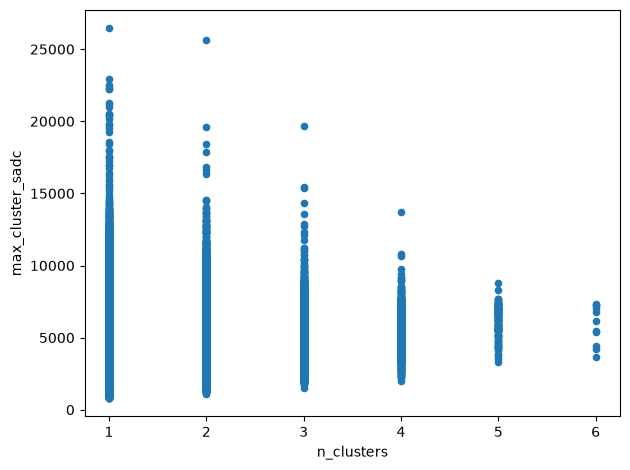

In [ ]:
from dunetrg.analysis.histograms import compute_regaxis_specs

# compute_regaxis_specs()


rad_insp_custers.query('readout_plane_id==2 & n_clusters > 0', inplace=True)

fig, axes = plt.subplots(1,2, figsize=(10,4))
ax=axes[0]
rad_insp_custers.max_cluster_sadc.hist(bins=100, ax=ax)

sadc_1Mev = 2.277e3

sadc_line = 8000
ax.axvline(x=8000, c='k', label='8000')

print(elec_calibrator.sadc_to_mev(8000))
energy = 4
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='--', label=f'{energy} MeV')
energy = 5
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-.', label=f'{energy} MeV')
energy = 10
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-', label=f'{energy} MeV')

# ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_ylabel('counts')
ax.set_title('radbkg - max cluster')
ax.set_yscale('log')
ax.legend()

ax=axes[1]
rad_insp_custers.n_clusters.hist(ax=ax)
ax.set_title('# clusters per window')

fig.tight_layout()


fig, axes = plt.subplots(1,1)
ax=axes
rad_insp_custers.plot.scatter(x='n_clusters', y='max_cluster_sadc', ax=ax)
fig.tight_layout()
